# Section 1: Notebook Setup & Imports

This section initializes the environment, sets up path resolution, imports libraries for modeling and evaluation, and configures the random seed for reproducibility. We also verify CUDA availability for XGBoost.

In [1]:
import os
import sys
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import torch
import xgboost as xgb
from xgboost import XGBRegressor

def find_project_root():
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for cand in candidates:
        if (cand / "data").exists() and (cand / "d_models").exists():
            return cand
    raise FileNotFoundError("Could not locate repo root containing 'data'")

PROJECT_ROOT = find_project_root()
print(f"Project root found: {PROJECT_ROOT}")

# Append project root to sys.path
sys_path_root = str(PROJECT_ROOT)
if sys_path_root not in sys.path:
    sys.path.append(sys_path_root)

# Import metrics dashboard from project utilities
try:
    from u_dashboard.dashboard import metrics_dashboard
    print("Imported dashboard from u_dashboard.dashboard")
except ImportError:
    try:
        from Models.Utils.dashboard import metrics_dashboard
        print("Imported dashboard from Models.Utils")
    except ImportError:
        from Utils.dashboard import metrics_dashboard
        print("Imported dashboard from local Utils")

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"Random seed set to {SEED}")

# Setup plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Verify CUDA/GPU availability for XGBoost
try:
    dummy = xgb.XGBRegressor(n_estimators=1, device="cuda")
    dummy.fit(np.array([[1.0]]), np.array([1.0]))
    XGB_DEVICE = "cuda"
    print("XGBoost CUDA support verified and enabled.")
except Exception as e:
    XGB_DEVICE = "cpu"
    print(f"XGBoost CUDA test failed ({e}). Falling back to CPU.")

print("Setup complete. Using device:", XGB_DEVICE)

Project root found: C:\Users\pan\Documents\GitHub\MDR-Project
Imported dashboard from u_dashboard.dashboard
Random seed set to 42
XGBoost CUDA support verified and enabled.
Setup complete. Using device: cuda


# Section 2: Data Loading & Preprocessing

This section loads the train, validation, and test splits for the `derived_8.1_pos` dataset. We concatenate the train and validation sets to form the `trainval` split for model training. We parse dates, extract the `year` and `month` features, and compute the temporal recency weights (Drift) using $\beta = 0.2$ as established in the `v25` baseline.

In [2]:
# Define path configurations
TRAIN_PATH = PROJECT_ROOT / "data/splits/derived_8.1_pos/train.csv"
VAL_PATH = PROJECT_ROOT / "data/splits/derived_8.1_pos/val.csv"
TEST_PATH = PROJECT_ROOT / "data/splits/derived_8.1_pos/test.csv"

# Load dataset splits
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset splits loaded:")
print(f"  train: {train_df.shape}")
print(f"  val:   {val_df.shape}")
print(f"  test:  {test_df.shape}")

# Parse date, extract month and year
for df in [train_df, val_df, test_df]:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month.astype(int)
    df["year"] = df["date"].dt.year.astype(float)

# Concatenate train and val for training+validation
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
print(f"  trainval (concatenated): {trainval_df.shape}")

# Compute temporal recency weights (Drift) with beta = 0.2
years_tv = trainval_df["year"]
max_year = years_tv.max()
beta = 0.2
w_trainval = np.exp(beta * (years_tv - max_year))
w_trainval = w_trainval / w_trainval.mean()

print(f"\nTemporal Recency Weighting (Drift) initialized with beta={beta}:")
print(f"  Min weight: {w_trainval.min():.4f}")
print(f"  Max weight: {w_trainval.max():.4f}")

Dataset splits loaded:
  train: (15964, 499)
  val:   (7149, 499)
  test:  (8902, 499)
  trainval (concatenated): (23113, 500)

Temporal Recency Weighting (Drift) initialized with beta=0.2:
  Min weight: 0.5828
  Max weight: 1.5843


# Section 3: Feature Sets Configuration

This section loads the two feature sets to be compared:
- **Feature Set A**: The 37 features from the `MDR-v25` baseline.
- **Feature Set B**: The 40 features (`OVERALL_SELECTED_FEATURES`) from `dataset_metadata.py`.

In [3]:
# Feature Set A: 37 features from MDR-v25.ipynb
FEATURE_SET_A = [
    'SMAP_sm_pm_interp_ema02',
    'V_rollmin_LST_modis_kobs30',
    'D_sin_DOY', 'G_rain_sum_3d',
    'V_ema_G_API_kobs7',
    'V_rollmin_G_API_kobs30',
    'G_rain_sum_7d',
    'C_lag_LST_modis_kobs30',
    'C_lag_G_API_kobs1',
    'V_ema_G_API_kobs14',
    'V_rollmean_G_API_kobs14',
    'G_API', 'G_DSLR',
    'SMAP_ampm_diff_interp',
    'V_rollmax_G_API_kobs30',
    'V_ema_G_API_kobs30',
    'V_rollmean_s2_b11_kobs7',
    'V_ema_LST_modis_kobs7',
    'V_rollmean_G_API_kobs7',
    'C_lag_s2_b11_kobs30',
    'A_d_E_SAR_diff_kobs14',
    'C_lag_LST_modis_kobs6',
    'A_d_LST_modis_kobs14',
    'A_d_SMAP_sm_interp_kobs14',
    'V_rollstd_SMAP_sm_interp_kobs30',
    'SMAP_sm_interp_grad7',
    'year_frac', 'sin_year', 'cos_year',
    'API_x_year', 'SMAP_x_year',
    'slope', 'elev', 'K_slope_sin',
    'K_slope_cos', 'K_aspect_cos',
    'J_clay_wfrac_b0', 'J_sand_wfrac_b0'
]

# Import Feature Set B from dataset_metadata
import importlib.util
metadata_path = PROJECT_ROOT / "data/splits/derived_8.1_pos/dataset_metadata.py"
spec = importlib.util.spec_from_file_location("dataset_metadata", metadata_path)
dataset_metadata = importlib.util.module_from_spec(spec)
spec.loader.exec_module(dataset_metadata)

FEATURE_SET_B = dataset_metadata.OVERALL_SELECTED_FEATURES
TARGET_COL = "soil_moisture_5cm"

print(f"Feature Set A (MDR-v25 Baseline) count: {len(FEATURE_SET_A)}")
print(f"Feature Set B (Overall Selected) count: {len(FEATURE_SET_B)}")

Feature Set A (MDR-v25 Baseline) count: 38
Feature Set B (Overall Selected) count: 40


# Section 4: Evaluation Utilities & Parameters

We define the metrics calculation utility and target variables. We also set up the hyperparameters for the XGBoost model configurations matching `MDR-v25.ipynb`:
- `XGB_PARAMS_NO_W`: The non-weighted baseline using `reg:absoluteerror`.
- `XGB_PARAMS_W`: The weighted baseline using `reg:pseudohubererror`.

In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    err = y_true - y_pred
    ae = np.abs(err)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    ubrmse = np.sqrt(np.mean(((y_true - np.mean(y_true)) - (y_pred - np.mean(y_pred))) ** 2))
    bias = np.mean(err)
    med_ae = np.median(ae)
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = float("nan")
    else:
        pearson = np.corrcoef(y_true, y_pred)[0, 1]
    return {
        "R2": r2, "RMSE": rmse, "ubRMSE": ubrmse, "Bias": bias, "MAE": mae, "Med|Err|": med_ae, "Pearson": pearson
    }

def print_metrics(metrics, title):
    print(f"\n===== {title} =====")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.5f}")

XGB_PARAMS_NO_W = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

XGB_PARAMS_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
    device=XGB_DEVICE
)

# Section 5: Model A Evaluation (37 Features from v25)

We train and evaluate two global XGBoost models using Feature Set A (37 features):
1. **Model A (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model A (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).

In [5]:
y_trainval = np.asarray(trainval_df[TARGET_COL]).ravel()
y_test = np.asarray(test_df[TARGET_COL]).ravel()

# 1. Non-weighted model
print("Training Model A (37 features, No Weights)...")
xgb_a_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
xgb_a_no_w.fit(trainval_df[FEATURE_SET_A], y_trainval, verbose=0)
pred_a_no_w = np.asarray(xgb_a_no_w.predict(test_df[FEATURE_SET_A])).ravel()
metrics_a_no_w = compute_metrics(y_test, pred_a_no_w)
print_metrics(metrics_a_no_w, "MODEL A (37 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
print("\nTraining Model A (37 features, Weighted)...")
xgb_a_w = XGBRegressor(**XGB_PARAMS_W)
xgb_a_w.fit(trainval_df[FEATURE_SET_A], y_trainval, sample_weight=w_trainval, verbose=0)
pred_a_w = np.asarray(xgb_a_w.predict(test_df[FEATURE_SET_A])).ravel()
metrics_a_w = compute_metrics(y_test, pred_a_w)
print_metrics(metrics_a_w, "MODEL A (37 FEAT, WEIGHTED) METRICS")

Training Model A (37 features, No Weights)...



===== MODEL A (37 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.62289
RMSE      : 0.06467
ubRMSE    : 0.05979
Bias      : -0.02463
MAE       : 0.04916
Med|Err|  : 0.03902
Pearson   : 0.82443

Training Model A (37 features, Weighted)...



===== MODEL A (37 FEAT, WEIGHTED) METRICS =====
R2        : 0.62799
RMSE      : 0.06423
ubRMSE    : 0.05985
Bias      : -0.02331
MAE       : 0.04914
Med|Err|  : 0.03798
Pearson   : 0.82467


# Section 6: Model B Evaluation (40 Features from metadata)

We train and evaluate two global XGBoost models using Feature Set B (40 features):
1. **Model B (No Weights)**: Trained with `reg:absoluteerror` objective and no sample weighting.
2. **Model B (Weighted)**: Trained with `reg:pseudohubererror` objective and temporal recency weights ($\beta=0.2$).

In [6]:
# 1. Non-weighted model
print("Training Model B (40 features, No Weights)...")
xgb_b_no_w = XGBRegressor(**XGB_PARAMS_NO_W)
xgb_b_no_w.fit(trainval_df[FEATURE_SET_B], y_trainval, verbose=0)
pred_b_no_w = np.asarray(xgb_b_no_w.predict(test_df[FEATURE_SET_B])).ravel()
metrics_b_no_w = compute_metrics(y_test, pred_b_no_w)
print_metrics(metrics_b_no_w, "MODEL B (40 FEAT, NO WEIGHTS) METRICS")

# 2. Weighted model
print("\nTraining Model B (40 features, Weighted)...")
xgb_b_w = XGBRegressor(**XGB_PARAMS_W)
xgb_b_w.fit(trainval_df[FEATURE_SET_B], y_trainval, sample_weight=w_trainval, verbose=0)
pred_b_w = np.asarray(xgb_b_w.predict(test_df[FEATURE_SET_B])).ravel()
metrics_b_w = compute_metrics(y_test, pred_b_w)
print_metrics(metrics_b_w, "MODEL B (40 FEAT, WEIGHTED) METRICS")

Training Model B (40 features, No Weights)...



===== MODEL B (40 FEAT, NO WEIGHTS) METRICS =====
R2        : 0.50233
RMSE      : 0.07429
ubRMSE    : 0.07327
Bias      : -0.01226
MAE       : 0.05483
Med|Err|  : 0.03985
Pearson   : 0.72018

Training Model B (40 features, Weighted)...



===== MODEL B (40 FEAT, WEIGHTED) METRICS =====
R2        : 0.49090
RMSE      : 0.07513
ubRMSE    : 0.07421
Bias      : -0.01177
MAE       : 0.05499
Med|Err|  : 0.04007
Pearson   : 0.71302


# Section 7: Comparative Summary & Visualization

We print the summary metrics table comparing the four configurations and generate residual scatter plots.


===== COMPARATIVE PERFORMANCE SUMMARY =====
                    Configuration     R2   RMSE ubRMSE    Bias    MAE Med|Err| Pearson
Model A (37 Features, No Weights) 0.6229 0.0647 0.0598 -0.0246 0.0492   0.0390  0.8244
  Model A (37 Features, Weighted) 0.6280 0.0642 0.0598 -0.0233 0.0491   0.0380  0.8247
Model B (40 Features, No Weights) 0.5023 0.0743 0.0733 -0.0123 0.0548   0.0398  0.7202
  Model B (40 Features, Weighted) 0.4909 0.0751 0.0742 -0.0118 0.0550   0.0401  0.7130


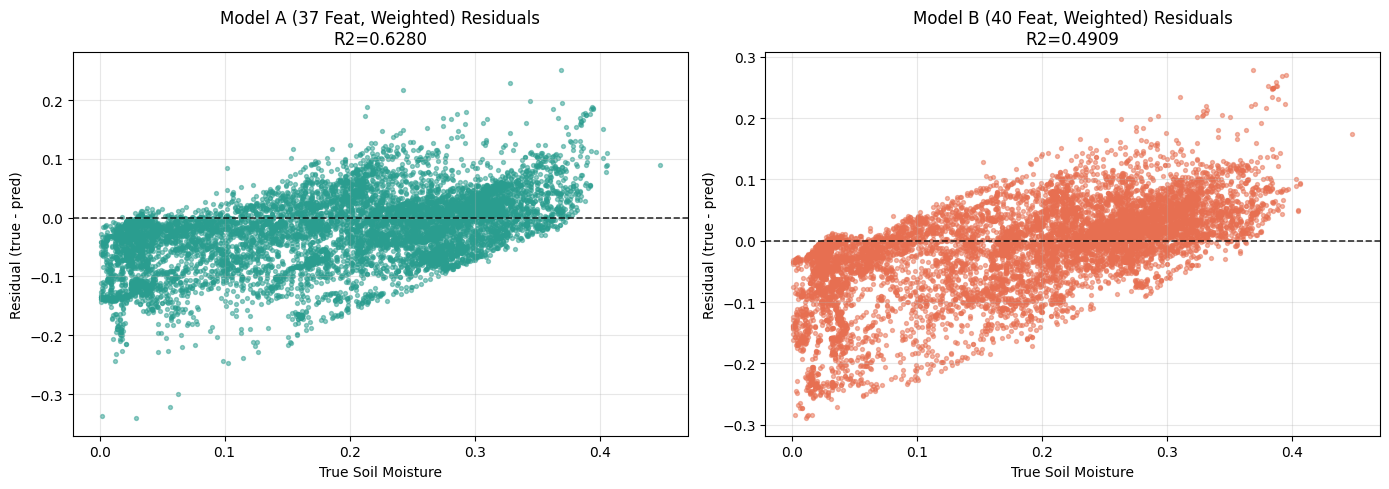

In [7]:
metrics_summary_data = {
    "Configuration": [
        "Model A (37 Features, No Weights)",
        "Model A (37 Features, Weighted)",
        "Model B (40 Features, No Weights)",
        "Model B (40 Features, Weighted)"
    ],
    "R2": [
        metrics_a_no_w["R2"],
        metrics_a_w["R2"],
        metrics_b_no_w["R2"],
        metrics_b_w["R2"]
    ],
    "RMSE": [
        metrics_a_no_w["RMSE"],
        metrics_a_w["RMSE"],
        metrics_b_no_w["RMSE"],
        metrics_b_w["RMSE"]
    ],
    "ubRMSE": [
        metrics_a_no_w["ubRMSE"],
        metrics_a_w["ubRMSE"],
        metrics_b_no_w["ubRMSE"],
        metrics_b_w["ubRMSE"]
    ],
    "Bias": [
        metrics_a_no_w["Bias"],
        metrics_a_w["Bias"],
        metrics_b_no_w["Bias"],
        metrics_b_w["Bias"]
    ],
    "MAE": [
        metrics_a_no_w["MAE"],
        metrics_a_w["MAE"],
        metrics_b_no_w["MAE"],
        metrics_b_w["MAE"]
    ],
    "Med|Err|": [
        metrics_a_no_w["Med|Err|"],
        metrics_a_w["Med|Err|"],
        metrics_b_no_w["Med|Err|"],
        metrics_b_w["Med|Err|"]
    ],
    "Pearson": [
        metrics_a_no_w["Pearson"],
        metrics_a_w["Pearson"],
        metrics_b_no_w["Pearson"],
        metrics_b_w["Pearson"]
    ]
}

summary_df = pd.DataFrame(metrics_summary_data)
print("\n===== COMPARATIVE PERFORMANCE SUMMARY =====")
print(summary_df.to_string(index=False, formatters={
    'R2': '{:,.4f}'.format,
    'RMSE': '{:,.4f}'.format,
    'ubRMSE': '{:,.4f}'.format,
    'Bias': '{:+,.4f}'.format,
    'MAE': '{:,.4f}'.format,
    'Med|Err|': '{:,.4f}'.format,
    'Pearson': '{:,.4f}'.format
}))

out_dir = PROJECT_ROOT / "notebooks/experiment/derived_8.1_pos-eval-3.0"
summary_df.to_csv(out_dir / "metrics_summary.csv", index=False)

# Plot residuals comparison
res_a_w = y_test - pred_a_w
res_b_w = y_test - pred_b_w

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, res_a_w, s=8, alpha=0.5, color='#2a9d8f')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title(f"Model A (37 Feat, Weighted) Residuals\nR2={metrics_a_w['R2']:.4f}")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, res_b_w, s=8, alpha=0.5, color='#e76f51')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_ylabel("Residual (true - pred)")
axes[1].set_title(f"Model B (40 Feat, Weighted) Residuals\nR2={metrics_b_w['R2']:.4f}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / "residuals_comparison.png")
plt.show()